In [1]:
# Pré-requisito: Instalação das bibliotecas no ambiente virtual
! pip install python-bcb beautifulsoup4 pandas matplotlib seaborn --upgrade

In [2]:
# 1. Importação das bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from bcb import Expectativas

In [3]:
# Configuração do estilo visual para padrão acadêmico
sns.set_theme(style="white", palette="muted")

In [14]:
# 2. Processamento de Linguagem Natural (Atas do Copom)
print("1. Extraindo Atas do Copom e processando análise de sentimento...\n")

# Calendário de reuniões selecionadas (Visão histórica)
calendario_copom = {
    237: '2021-03-17', 245: '2022-03-16', 253: '2023-03-22',
    261: '2024-03-20', 269: '2025-03-19', 277: '2026-03-18'
}

1. Extraindo Atas do Copom e processando análise de sentimento...



In [15]:
# Nota metodológica: O uso de radicais (Stemming) permite capturar variações
# morfológicas (ex: 'desancorag' captura 'desancoragem' e 'desancoradas')
lexico_hawkish = [
    'risco', 'cautela', 'aperto', 'desancorag', 'vigilância', 'alta',
    'deterioração', 'pressão', 'restritiv', 'resiliência', 'choque',
    'persistênci', 'prolongad', 'assimetria', 'incerteza', 'preocupação'
]

lexico_dovish = [
    'arrefecimento', 'estímulo', 'flexibiliza', 'ociosa', 'queda',
    'ancorada', 'acomodatíci', 'recuperação', 'suave', 'desaceleração',
    'benigno', 'declínio', 'moderação', 'transitóri', 'suporte'
]

dados_nlp = []

# Loop de varredura nas atas via API de Dados Abertos
for nro, data in calendario_copom.items():
    url = f'https://www.bcb.gov.br/api/servico/sitebcb/copom/atas_detalhes?nro_reuniao={nro}'
    resp = requests.get(url)

    if resp.status_code == 200:
        # Limpeza das tags HTML e conversão para minúsculas
        texto_ata = BeautifulSoup(str(resp.json()), 'html.parser').get_text().lower()

        # Cálculo da frequência léxica e geração do indicador
        s_hawk = sum(texto_ata.count(t) for t in lexico_hawkish)
        s_dove = sum(texto_ata.count(t) for t in lexico_dovish)
        score_liq = s_hawk - s_dove

        # Log de auditoria visual do NLP
        print(f"Ata {nro} ({data[:4]}) | Hawkish: {s_hawk:02d} | Dovish: {s_dove:02d} | Score Líquido: {score_liq}")

        dados_nlp.append({'Data': pd.to_datetime(data), 'Sentimento_Liquido': score_liq})

# Estruturação do DataFrame de NLP
df_nlp = pd.DataFrame(dados_nlp).sort_values('Data')

Ata 237 (2021) | Hawkish: 30 | Dovish: 18 | Score Líquido: 12
Ata 245 (2022) | Hawkish: 49 | Dovish: 01 | Score Líquido: 48
Ata 253 (2023) | Hawkish: 45 | Dovish: 23 | Score Líquido: 22
Ata 261 (2024) | Hawkish: 42 | Dovish: 16 | Score Líquido: 26
Ata 269 (2025) | Hawkish: 43 | Dovish: 15 | Score Líquido: 28
Ata 277 (2026) | Hawkish: 29 | Dovish: 18 | Score Líquido: 11


In [16]:
# 3. Coleta de Expectativas (Boletim Focus)
em = Expectativas()
ep = em.get_endpoint('ExpectativasMercadoAnuais')

In [17]:
# Extração das projeções do IPCA desde 2020
df_focus = (ep.query()
            .filter(ep.Indicador == 'IPCA')
            .filter(ep.Data >= '2020-01-01')
            .select(ep.Data, ep.DataReferencia, ep.Mediana)
            .collect())

df_focus.rename(columns={'Mediana': 'Focus_IPCA'}, inplace=True)
df_focus['Data'] = pd.to_datetime(df_focus['Data'])

In [18]:
# Filtragem: capturar apenas a expectativa referente ao ano corrente da ata
df_focus = df_focus[df_focus['DataReferencia'] == df_focus['Data'].dt.year.astype(str)]
df_focus = df_focus.sort_values('Data').drop_duplicates(subset=['Data'], keep='last')

In [19]:
# 4. Alinhamento Cronológico das Bases (Merge As Of)
# Associa a ata do Copom à expectativa do Focus imediatamente anterior
df_final = pd.merge_asof(df_nlp, df_focus, on='Data', direction='backward')
df_final.set_index('Data', inplace=True)
print("Bases cruzadas com sucesso! Inicializando visualização...\n")

Bases cruzadas com sucesso! Inicializando visualização...



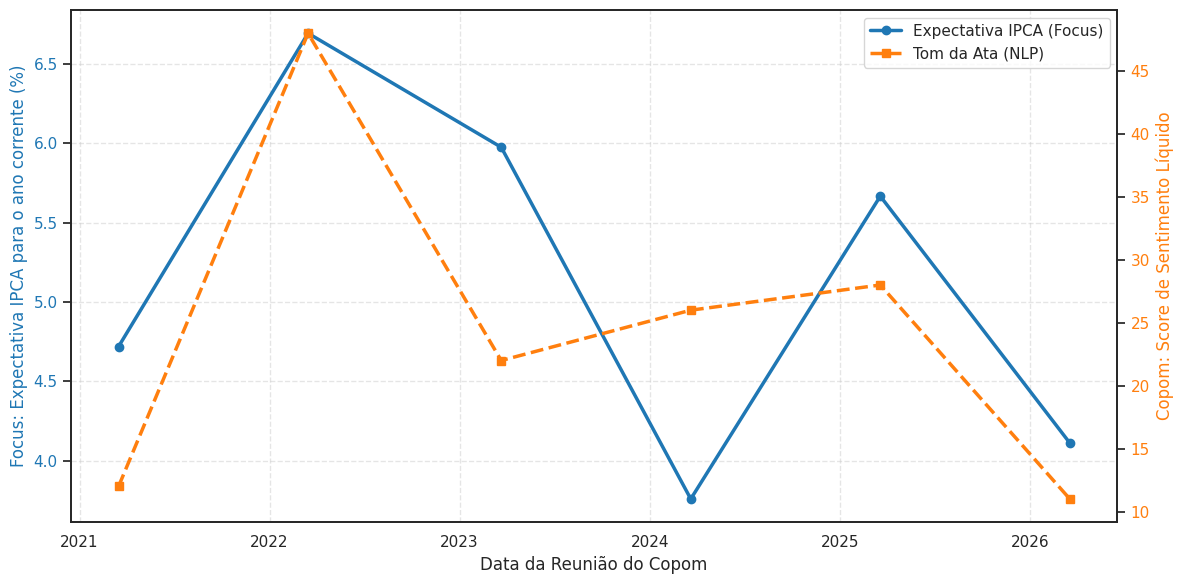

In [20]:
# 5. Geração do Gráfico (Eixos Duplos)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo Esquerdo: Expectativas Focus (Quantitativo)
cor_focus = '#1f77b4'
ax1.set_xlabel('Data da Reunião do Copom', fontsize=12)
ax1.set_ylabel('Focus: Expectativa IPCA para o ano corrente (%)', color=cor_focus, fontsize=12)
linha_1 = ax1.plot(df_final.index, df_final['Focus_IPCA'], color=cor_focus, marker='o', linewidth=2.5, label='Expectativa IPCA (Focus)')
ax1.tick_params(axis='y', labelcolor=cor_focus)
ax1.grid(True, linestyle='--', alpha=0.5)

# Eixo Direito: Sentimento Copom (Qualitativo via NLP)
ax2 = ax1.twinx()
cor_nlp = '#ff7f0e'
ax2.set_ylabel('Copom: Score de Sentimento Líquido', color=cor_nlp, fontsize=12)
linha_2 = ax2.plot(df_final.index, df_final['Sentimento_Liquido'], color=cor_nlp, marker='s', linewidth=2.5, linestyle='--', label='Tom da Ata (NLP)')
ax2.tick_params(axis='y', labelcolor=cor_nlp)

# Unificação das legendas
linhas_totais = linha_1 + linha_2
legendas_totais = [l.get_label() for l in linhas_totais]
ax1.legend(linhas_totais, legendas_totais, loc='upper right', frameon=True, fontsize=11)

plt.tight_layout()
plt.show()